# Video Analysis with Gemini

This demo notebook showcases how to perform analysis on unstructured data like videos with Gemini in BQ via BQML. There are 2 use cases described here:



1.   The first use case showcases the use of Gemini to summarize a video (with
information like no. of speakers, topics etc)
2.   The second use case explores how an insurance company can analyse videos of cars with damage and extract insights/data points from it and then use it to train a predicting ML model that can be used for insurance premium calculation.

Refer to reference:

*  [go/demo site](https://cloud-demo-hub.corp.google.com/demo/Video-analysis-with-BQML-using-Gemini/985)
* [original colab material](https://colab.sandbox.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/use-cases/video-analysis/video_analysis.ipynb#scrollTo=KzqjpEiryjNo)







## Getting Started


In [1]:
# Define project information
PROJECT_ID = "lohk-da-coaching"  # @param {type:"string"}
LOCATION = "us-central1"  # @param {type:"string"}
CONNECTION_ID = "vertex_llm"  # @param {type:"string"}
REGION = "US"  # @param {type: "string"}
DATASET_ID = "bqml"  # @param {type:"string"}

# Initialize Vertex AI
import vertexai

vertexai.init(project=PROJECT_ID, location=LOCATION)

### Import libraries


In [2]:
from IPython.display import Markdown, Video, display

from vertexai.preview.generative_models import (
    GenerationConfig,
    GenerativeModel,
    HarmCategory,
    HarmBlockThreshold,
    Part,
)

import bigframes.pandas as bf

from google.cloud import bigquery
from google.cloud import storage

# Construct a BigQuery client object.
client = bigquery.Client()

import pandas as pd
from IPython.display import Image, display
from PIL import Image as PILImage
import io

### Load the Gemini  model

Gemini Flash is a multimodal model that supports multimodal prompts. You can include text, image(s), PDFs, audio, and video in your prompt requests and get text or code responses.

In [3]:
model = GenerativeModel("gemini-2.0-flash")

generation_config = GenerationConfig(temperature=1, top_p=0.95, max_output_tokens=8192)

safety_settings = {
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
}

### Helper functions

In [4]:
def get_url_from_gcs(gcs_uri: str) -> str:
    # converts gcs uri to url for display.
    return gcs_uri.replace("gs://", "https://storage.googleapis.com/").replace(
        " ", "%20"
    )

##  Use case 1: Analysis from Video and Audio

For this example, we will be analyzing a 7 min clip from Google Cloud Next around what is new in DA.

A hour long video,  is roughly equivalent to 1 Million Tokens for Gemini 1.5 Pro.
This video is roughly 7 minutes long. It is equivalent to ~125k tokens

We will analyze it using Gemini Pro and Flash using both Vertex & BQML

#### Using Vertex AI LLM to analyze video content

Analyze a **short video** on Booking.com

In [5]:
video_analysis_prompt = """You are an expert in analyzing videos. Provide a concise summary of the video provided. \
Include the following : (1) Overall summary of the video \
(2) How many people were speaking in the video \
(3) What type of locations are shown in the video \
(4) Which is the purpose of this video
(5) What were said in the video"""

video_analysis_prompt

'You are an expert in analyzing videos. Provide a concise summary of the video provided. Include the following : (1) Overall summary of the video (2) How many people were speaking in the video (3) What type of locations are shown in the video (4) Which is the purpose of this video\n(5) What were said in the video'

In [7]:
# Load file directly from Google Cloud Storage
video_uri = "gs://lohk-da-demo/misc_videos/booking-anniversary-celebration.mp4"

# Load contents
contents = [
    Part.from_uri(
        uri=video_uri,
        mime_type="video/mp4",
    ),
    video_analysis_prompt,
]

# Display the Video
#display(Video(get_url_from_gcs(video_uri)))

# Send to Gemini
response = model.generate_content(contents, generation_config=generation_config)

# Display results
display(Markdown(response.text))

Here's a concise summary of the video:

**(1) Overall Summary:**
The video is a humorous commercial for Booking.com, featuring Tina Fey and her body doubles. It highlights the variety of travel options available on the site and the ability to become whoever you want on your vacation. The commercial ends with an appearance by Glenn Close.

**(2) Number of Speakers:**
There are two speakers in the video: Tina Fey and Glenn Close.

**(3) Types of Locations:**
The video showcases a variety of travel destinations and accommodations, including luxury hotels, cabins, romantic suites, buffets at hotels, Texas farm stays, and scenic outdoor areas.

**(4) Purpose of the Video:**
The purpose of the video is to advertise Booking.com as a platform for booking accommodations and experiences, showcasing its wide range of options and appealing to consumers.

**(5) What were said in the video:**
- Tina Fey mentions that with so many choices on Booking.com, there are so many Tina Feys she could be and hired body doubles to help her out.
- One body double mentions Family Tina who loves a hotel with breakfast included and the other says, "Tina you're allergic to wheat."
- Another body double mentions Romantic Tina who booked a cozy suite for two and said that thanks to free cancellations, she can become non-committal Tina.
- Tina Fey asks if Glenn Close is her nemesis.
- Glenn Close states that on Booking.com, you can book whoever you want to be.
- Tina Fey jokes: that's her line.
- The commercial ends with Booking.yeah, which is the new tagline for Booking.com.


In [10]:
# get extra information from the response, including the token consumed
print(response)
print("Token consumed:")
print(model.count_tokens(contents))

candidates {
  content {
    role: "model"
    parts {
      text: "Here\'s a concise summary of the video:\n\n**(1) Overall Summary:**\nThe video is a humorous commercial for Booking.com, featuring Tina Fey and her body doubles. It highlights the variety of travel options available on the site and the ability to become whoever you want on your vacation. The commercial ends with an appearance by Glenn Close.\n\n**(2) Number of Speakers:**\nThere are two speakers in the video: Tina Fey and Glenn Close.\n\n**(3) Types of Locations:**\nThe video showcases a variety of travel destinations and accommodations, including luxury hotels, cabins, romantic suites, buffets at hotels, Texas farm stays, and scenic outdoor areas.\n\n**(4) Purpose of the Video:**\nThe purpose of the video is to advertise Booking.com as a platform for booking accommodations and experiences, showcasing its wide range of options and appealing to consumers.\n\n**(5) What were said in the video:**\n- Tina Fey mentions that

##  Use case: Insurance video analysis

Insurance companies will have short videos that customers may upload of their cars to get a insurance premium quotation, or a damage repair quote.

Gemini can analyze the video and output a json of key aspects that can be stored in a table for further downstream analysis.

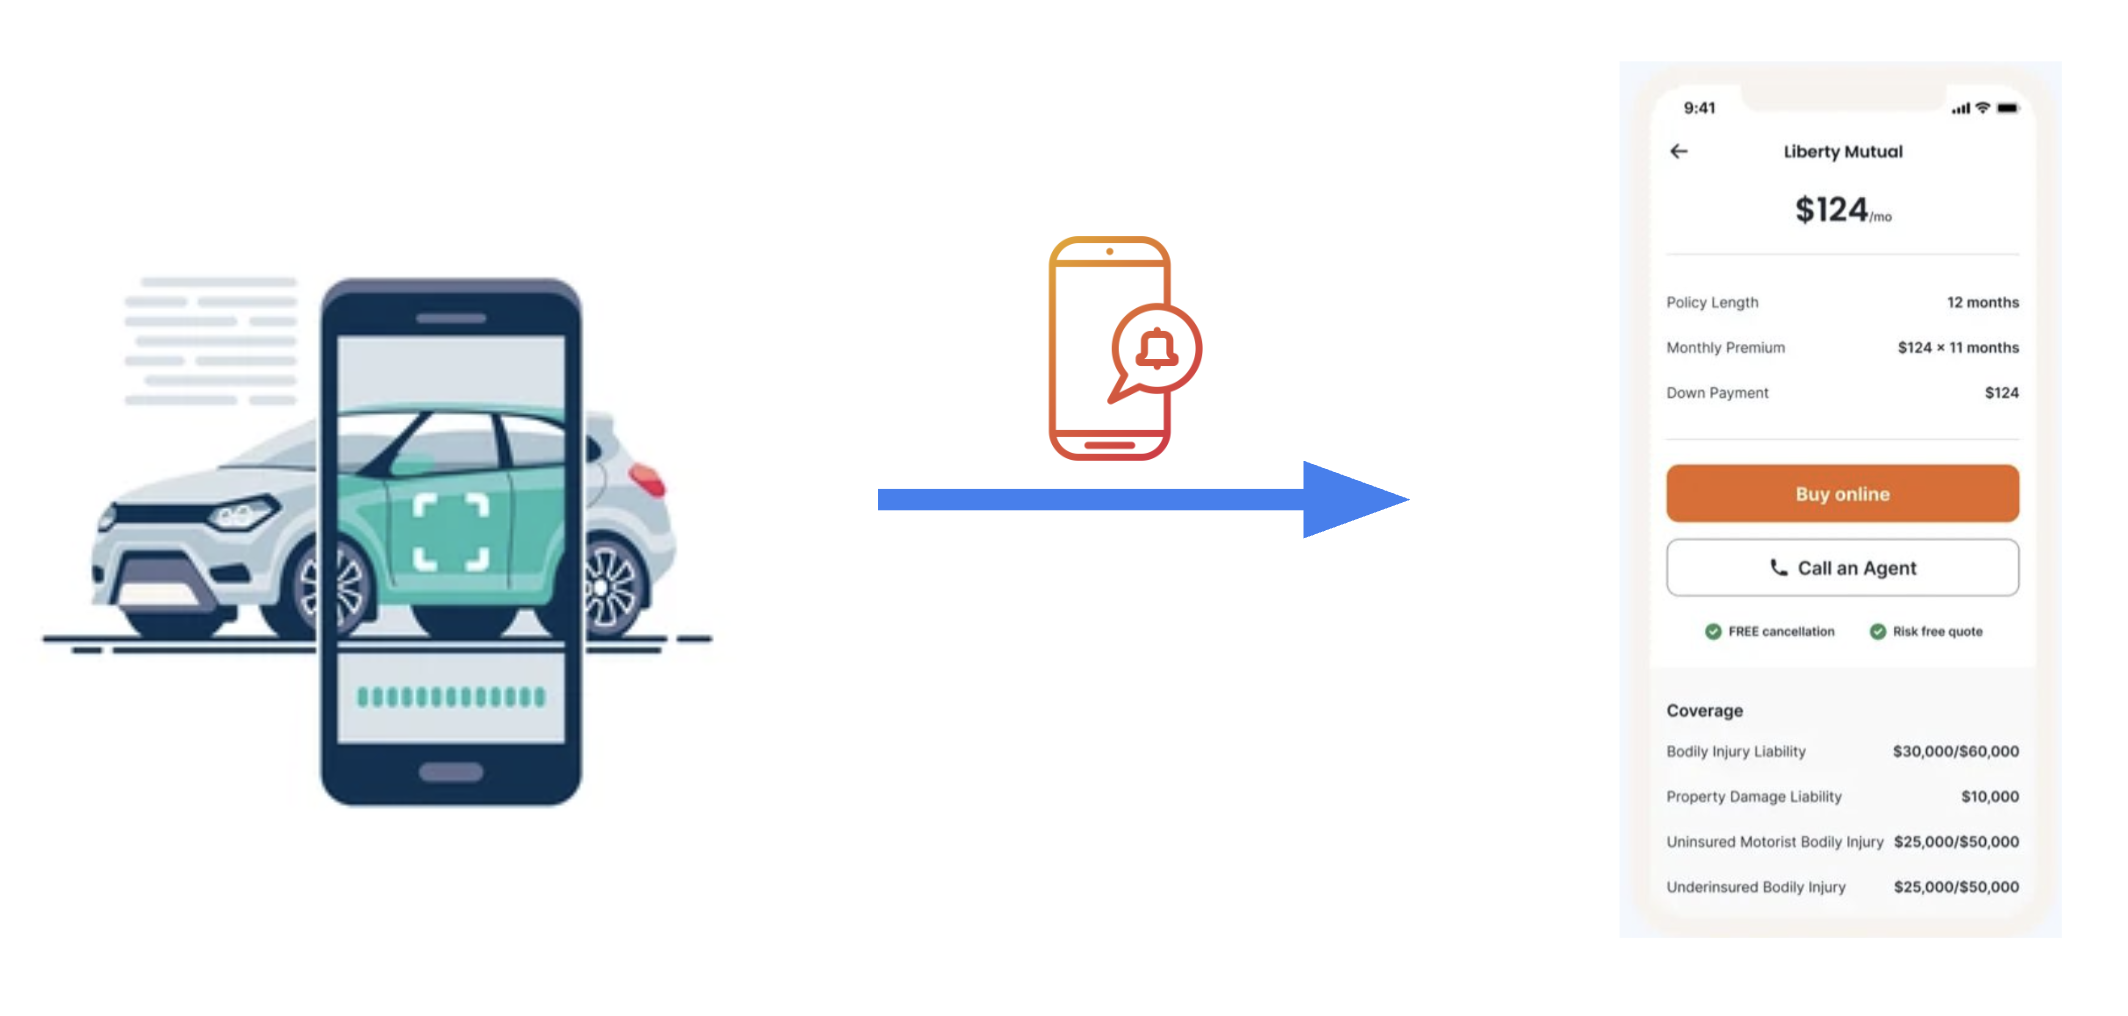

#### Using BQML

In [5]:
## Create object table

%%bigquery
CREATE OR REPLACE EXTERNAL TABLE bqml.video_object_table
WITH CONNECTION `us.vertex_llm`
Options(object_metadata="DIRECTORY", uris=["gs://lohk-da-demo/car_videos/*"]);

select * from bqml.video_object_table;


Query is running:   0%|          |

Downloading:   0%|          |

,uri,generation,content_type,size,md5_hash,updated,metadata
0,gs://lohk-da-demo/car_videos/1.mp4,1745584195069831,video/mp4,84497978,34ff329b0d1307dfc5e0ba5d721682d2,2025-04-25 12:29:55.119000+00:00,[]
1,gs://lohk-da-demo/car_videos/10.mp4,1745584195081427,video/mp4,48237229,42bee31a1f96c19218ae80aa8350822f,2025-04-25 12:29:55.134000+00:00,[]
2,gs://lohk-da-demo/car_videos/2.mp4,1745584195083558,video/mp4,103842574,4540d181e9e5d2e35715050c2f5d0208,2025-04-25 12:29:55.138000+00:00,[]
3,gs://lohk-da-demo/car_videos/3.mp4,1745584195066936,video/mp4,48811464,c14d03cee8aeac50f828d778cc273ba0,2025-04-25 12:29:55.103000+00:00,[]
4,gs://lohk-da-demo/car_videos/4.mp4,1745584195150550,video/mp4,50063252,cb98a490fe996ed4c7a1681c03eca108,2025-04-25 12:29:55.187000+00:00,[]
5,gs://lohk-da-demo/car_videos/5.mp4,1745584195069048,video/mp4,49579082,f1f0c2b010d1ebcf55ec53bd98cfdf14,2025-04-25 12:29:55.123000+00:00,[]
6,gs://lohk-da-demo/car_videos/6.mp4,1745584195070726,video/mp4,48778501,b45e5760f97d1267974843e256d284b7,2025-04-25 12:29:55.121000+00:00,[]
7,gs://lohk-da-demo/car_videos/7.mp4,1745584195529157,video/mp4,46631645,1a61632d6cf93861647db70ca0463afe,2025-04-25 12:29:55.568000+00:00,[]
8,gs://lohk-da-demo/car_videos/8.mp4,1745584195064569,video/mp4,49794037,dd922cac6b0019c650036392385ca30f,2025-04-25 12:29:55.119000+00:00,[]
9,gs://lohk-da-demo/car_videos/9.mp4,1745584195078200,video/mp4,44338690,68c448758abba670b4740a0ea729fbf0,2025-04-25 12:29:55.124000+00:00,[]


In [6]:
%%bigquery --project $PROJECT_ID
# create gemini vision pro model
CREATE OR REPLACE MODEL `bqml.gemini_flash_model`
REMOTE WITH CONNECTION DEFAULT
OPTIONS(endpoint='gemini-2.0-flash-001');

Query is running:   0%|          |

""


In [7]:
# create a prompt
car_video_analysis_prompt = """You are an expert insurance agent specializing in analyzing videos of cars. Provide a concise summary of the video provided. \
Include the following : \
(1) The make and model of the car \
(2) Assess the condition of the paint and body panels for any scratches, dents, or rust.\
(3) Note any modifications to the car, like aftermarket parts or custom paint. \
(4) If ther is damage, Estimate the potential cost of repairs for identified damage."""

## inferencing
query = ('''
SELECT ml_generate_text_llm_result, uri FROM
ML.GENERATE_TEXT(
  MODEL `bqml.gemini_flash_model`,
  TABLE `bqml.video_object_table`,
  STRUCT(true as flatten_json_output, 1024 as max_output_tokens, '{video_analysis_prompt}' as prompt))
  ''').format(video_analysis_prompt = car_video_analysis_prompt)

client.query(query).to_dataframe()


,ml_generate_text_llm_result,uri
0,"Okay, here's an insurance assessment of the ve...",gs://lohk-da-demo/car_videos/1.mp4
1,"Okay, here's an insurance agent's summary of t...",gs://lohk-da-demo/car_videos/10.mp4
2,"Okay, here's an insurance assessment of the ve...",gs://lohk-da-demo/car_videos/2.mp4
3,"Okay, here's an insurance assessment of the ve...",gs://lohk-da-demo/car_videos/3.mp4
4,"Okay, here's an insurance assessment of the ve...",gs://lohk-da-demo/car_videos/4.mp4
5,"Okay, here's my assessment of the vehicle in t...",gs://lohk-da-demo/car_videos/5.mp4
6,"Okay, here's an insurance assessment of the ve...",gs://lohk-da-demo/car_videos/6.mp4
7,"Okay, here's my assessment of the car in the v...",gs://lohk-da-demo/car_videos/7.mp4
8,"Okay, here's a summary of the car video from a...",gs://lohk-da-demo/car_videos/8.mp4
9,"Okay, here's a summary of the car in the video...",gs://lohk-da-demo/car_videos/9.mp4


In [16]:
## Modified prompt for output in a json file to add to a table
car_video_analysis_prompt_json = """You are an expert insurance agent specializing in analyzing videos of cars. \
From the video provided identify the following: \
1. number plate of the car. \
2. brand of the car. \
3. model of the car. \
4. color of the car. \
5. assess its overall condition. (e.g. paint situation, clealiness, appears new or used, well-maintained, showing wear, etc). \
6. if any damage is visible in the video, provide a very detailed text analysis of each instance, including the type of damage like scratch, dent, crack, etc, its location on the vehicle (e.g., front bumper, driver side door), its estimated size and severity, and any other relevant observations (e.g., paint missing, deformation of parts). \
Ensure the values adhere to the allowed options specified above. If you are unable to confidently determine a value, leave it blank. \
Answer in a validated JSON format with only following keys: number_plate, car_brand, car_model, car_color, analysis, damage_details. The values should be string type. Do not add text outside of json structure. \
"""

## enrich your unstructured data (video) with structured data from Gemini
query = ('''
WITH raw_json_result AS (
SELECT
   uri,
   ml_generate_text_llm_result as gemini_output
 FROM
   ML.GENERATE_TEXT(
     MODEL `bqml.gemini_flash_model`,
     TABLE `bqml.video_object_table`,
     STRUCT(
     '{PROMPT_TXT}' AS prompt,
      0.2 AS temperature,
      4000 AS max_output_tokens,
      TRUE AS flatten_json_output)))
SELECT
    uri,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.number_plate") AS number_plate,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.car_brand") AS car_brand,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.car_model") AS car_model,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.car_color") AS car_color,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.analysis") AS analysis,
    JSON_QUERY(RTRIM(LTRIM(raw_json_result.gemini_output, " ```json"), "```"), "$.damage_details") AS damage_details
FROM raw_json_result;
''').format(PROMPT_TXT = car_video_analysis_prompt_json);

client.query(query).to_dataframe()

,uri,number_plate,car_brand,car_model,car_color,analysis,damage_details
0,gs://lohk-da-demo/car_videos/1.mp4,"""6966 EA-2""","""Mercedes-Benz""","""C-Class""","""Silver""","""The car appears to be used and generally well...","""No visible damage detected in the video."""
1,gs://lohk-da-demo/car_videos/10.mp4,"""1673 IK-2""","""Toyota""","""Camry""","""Gray""","""The car appears to be used and generally well...","""No visible damage."""
2,gs://lohk-da-demo/car_videos/2.mp4,"""7772 EM-2""","""Citroen""","""C5""","""Silver""","""The car appears to be used and generally well...","""There is a visible dent on the front driver's..."
3,gs://lohk-da-demo/car_videos/3.mp4,"""6294 IP-2""","""RENAULT""","""MEGANE""","""silver""","""The car appears to be used and showing some w...",None
4,gs://lohk-da-demo/car_videos/4.mp4,"""3314 EP-2""","""Hyundai""","""Solaris""","""Orange""","""The car appears to be used and showing some w...","""There is damage to the rear bumper on the pas..."
5,gs://lohk-da-demo/car_videos/5.mp4,"""6216 IK-2""","""Renault""","""Duster""","""Silver""","""The car appears to be in good, well-maintaine...","""No visible damage."""
6,gs://lohk-da-demo/car_videos/6.mp4,"""P947OT777""","""Toyota""","""Prius""","""blue""","""The car appears to be used and showing some w...","""There is a scratch on the driver's side door ..."
7,gs://lohk-da-demo/car_videos/7.mp4,"""8006 EK-2""","""Renault""","""Twingo""","""white""","""The car appears to be used and generally well...","""There is a scratch on the driver's side door,..."
8,gs://lohk-da-demo/car_videos/8.mp4,"""7736 IP-2""","""Mercedes-Benz""","""C 220""","""blue""","""The car appears to be used and showing wear. ...","""There is a dent on the front passenger side f..."
9,gs://lohk-da-demo/car_videos/9.mp4,"""6183 IP-2""","""Volkswagen""","""Golf Plus""","""dark blue""","""The car appears to be used and showing wear. ...",None


We have seen above how we can extract structured insights from video (or other forms of unstrucutred data be it images/audio etc). This can now be used further downstream with other data the company might have on whether the claim was approved/amount of the claim etc, and train a predictive AI model for claim approval. In this demo, we have just worked with 10 files, but in practice companies will have a lot more data which they can use to train future ML models.